### === Temporal Response Function ===


Step by Step:

1. Getting Audio Envelope:
    + Read Waveforms
    + eelBrains NDVar representation
    + transform to Gamma-tone Bank --> eel.gammatone_bank 256 frequencies, signal, mono
    + Resmaple to 1000
    + Power rescaling bhy absolute ^ 0.6
    + **Envelope** by Summing gt_cmp an using FIR of 20 Hz  and order 662 and resample to 100Hz to Match Occular Data 

2. Extracting Data: 
    + **LeftPupil:** already preprocessed, taking only Low Pass filter of 20Hz Ignoring NANs
    + **X:** already preprocessed, taking only Low Pass filter of 20Hz Ignoring NANs
    + **Y:** already preprocessed, taking only Low Pass filter of 20Hz Ignoring NANs
    + **GazeDifference:** Getting a difference of X and Y Eye Position, computing NaN + 1 roll matrix, and computing euclidean distance between Non NaN trials of X and Y. Then filtering by Non NaN 20Hz filter


3. Getting Last 10s of Data 

4. Resampling our measures to 50Hz 


5. TRF:
    + Get All Data from a given Subject (Train) EXCEPT current trial (Test)
    + Zscore - without NaNs our X (AudioEnvelope) and Y (occular data) for bot htest and train
    + Build a Lag marix - creating a Laggs between -100 to 500s - adjust by making a matrix of Xs with respect to Lags: 
    + Adding a constant to Lagged Matrices of Train and Test to get a proper model Matrix: 
    + making an OLS with regularization with alpha 0.001
    + Predicting by our model on a X_test (audio test)
    + Mask by gettting both Pred and Test NANs in signal: Getting only Non NAN predictions
    + Computing SpearmanR correlation 
    + Computing Z value by getting arcus hyperborical tangens out of Correlation. Reporting both

6. Testng
    + 

This notebook is devised to compute TRF function of Auditory Envelope of a signal vs Pupilary and other Responses

In [124]:
### PReambules:
import os
import pickle


### Analysis Oprions and Naming
est            = 'zscore'  # Whether to Zscore the data: # 'Zscore' or ''  
partial        = ''        # Whetheer to test Part of Experiment (first or second half): # 'first' or 'second' or ''
excludeDs      =["DS04", "DS25"] #["DS03", "DS08","DS14","DS23"]#["DS03", "DS08","DS14","DS23"]  # DS04 or DS25  # Excludsion of given subjects (List)
excludeDSTrial = []        # Exclusion of specific trials in a given DS: # construct our tuple out of values from both olumn thus making it easier to compare via isin() 
if len(excludeDs) >0:
    exclusionName= '_'.join(excludeDs)
else:
    exclusionName= ''

## Paths
workingDir = os.getcwd();
currentANalysisName = "NEW_TEST_withoutCenter_resVAR100_dgv5_bll500_blb75_smw10_smL2000_swG50_trOall_trB5000mean"
ExpName             = 'FirstExperiment'  # 'FirstExperiment' or 'SecondExp'
audioPath = r"C:\Users\barak\Documents\GitHub\startegicMW_lite\TextToSpeech\Story3_AI"
dfAnalysisName = "GazeVelocity" # Name of a TRF model being Trained


trialLength = 'All';
dfAnalysisList = ['GazeDifference','GazeVelocity','LeftPupil','X','Y']

subjects = [f for f in os.listdir(os.path.join(workingDir,ExpName,currentANalysisName,'individuals')) if  not os.path.isfile(os.path.join(os.path.join(workingDir,ExpName,currentANalysisName,'individuals'), f))] # get all the filenames




In [125]:
currentANalysisName = "NEW_TEST_withoutCenter_resVAR100_dgv5_bll500_blb75_smw10_smL2000_swG50_trOall_trB5000mean"


In [126]:
os.path.join(workingDir,ExpName,currentANalysisName,'segmentsAudioEnv.pkl')

'c:\\Users\\barak\\Documents\\GitHub\\startegicMW_lite\\Experiment\\analysis\\FirstExperiment\\NEW_TEST_withoutCenter_resVAR100_dgv5_bll500_blb75_smw10_smL2000_swG50_trOall_trB5000mean\\segmentsAudioEnv.pkl'

In [127]:
import numpy as np
from scipy.io import wavfile
import eelbrain as eel

from scipy.signal import firwin, filtfilt

fs = 1000
cutoff = 20
order = 662

from scipy.signal import resample_poly


fir = firwin(
    numtaps=order + 1,
    cutoff=cutoff,
    fs=fs,
    window='hamming'
)

segmentsAudio = {};
if os.path.isfile(os.path.join(workingDir,ExpName,currentANalysisName,'segmentsAudioEnv.pkl')):
    segmentsAudio = pickle.load(open(os.path.join(workingDir,ExpName,currentANalysisName,'segmentsAudioEnv.pkl'),'rb'))
else:
    for num,segm in enumerate(os.listdir(audioPath)):
        print(f"Segment {num+1}: {segm}")
        audioWaveform = wavfile.read(os.path.join(audioPath,segm))

        ### Transform to NDVar (Eelbrain container for data)
        audioWaveformNDVar = eel.NDVar(audioWaveform[1],   eel.UTS(0, 1/audioWaveform[0], len(audioWaveform[1])))

        ### Gammatone spectrogram
        gt = eel.gammatone_bank(audioWaveformNDVar,
            f_min=20,f_max=5000,n=256,  # number of frequency bands
            location='left'           # mono signal
        )

        ### Rescaling  and Resampling
        gt_rs = eel.resample(gt, 1000)
        
        # Power Law Comprssion (WHy???) 
        gt_comp = np.abs(gt_rs) ** 0.662

        # Get an envelope by summing the scaled frequency bands:
        envelope = np.sum(gt_comp,0)
        envelope_lp = filtfilt(fir, [1.0], envelope)
        envelope_lp = envelope_lp[::10]


        segmentsAudio[int(segm.strip('.wav').strip('segm_'))] = envelope_lp

In [128]:
segmentsAudio.keys()

import pickle as pkl

pkl.dump(segmentsAudio, open(os.path.join(workingDir,ExpName,currentANalysisName,'segmentsAudioEnv.pkl'),'wb'))

In [129]:

### Get All Preprocessed Data in a single Variable
import pandas as pd
gazeData = []
subjDict = {}

def filtfilt_ignore_nan(x, b):
    x = x.copy()
    isnan = np.isnan(x)

    if isnan.all():
        return x

    valid = ~isnan
    idx = np.where(np.diff(valid.astype(int)) != 0)[0] + 1
    segments = np.split(np.arange(len(x)), idx)

    for seg in segments:
        if valid[seg].all() and len(seg) > len(b)*3:
            x[seg] = filtfilt(b, [1.0], x[seg])

    return x


fs = 100
cutoff = 20
order = 201
from scipy.signal import firwin, filtfilt

fir = firwin(order + 1, cutoff, fs=fs)

def lp_and_decimate(x,fir):
    x_lp = filtfilt(fir, [1.0], x)
    return x_lp 
from scipy.stats import zscore

originalBeg = {};
pupilMWs_all = []
SaccadeData_all = [];
if os.path.isfile(os.path.join(workingDir,ExpName,currentANalysisName,f"TRF_raw.pkl")):
    gazeData = pickle.load(open(os.path.join(workingDir,ExpName,currentANalysisName,f"TRF_raw.pkl"),'rb'))
for i,subj in enumerate(subjects):
    print(f"DS{int(i+1):02d}: Processing subject {subj}")
    subjDict[f"DS{int(i+1):02d}"] = subj
    with open(os.path.join(workingDir,ExpName,currentANalysisName,'individuals',subj,f"{subj}_preprocessed.pickle"), 'rb') as file:
        currData = pickle.load(file)  # Call load method to deserialze
        #shutil.copyfile(os.path.join(workingDir,ExpName,currentANalysisName,'individuals',subj,f"{subj}_preprocessed.pickle"), os.path.join(os.path.split(workingDir)[0],'DataPack',ExpName,f"{subj}_preprocessed.pickle"))
        currData['pupilMW']['DS'] = subj
        currData['pupilMW']['trialNum'] = list(range(0,40))
        pupilMWs_all.append( currData['pupilMW'][['DS','trialNum','MW Estimate','Tracking',]])

        if os.path.isfile(os.path.join(workingDir,ExpName,currentANalysisName,f"TRF_raw.pkl")):
            continue
        else:
            for num,trial in enumerate(list(currData['data']['STORY_1'].keys())):
                ## add supplementary information about the DS and Trial Number as well as Tracking and MW Estimates:
                
                currData['data']['STORY_1'][trial]['Gaze']['DS'] = subj;
                currData['data']['STORY_1'][trial]['Gaze']['trialNum'] = num;
                currData['data']['STORY_1'][trial]['Gaze']['MW_Estimate'] = currData['pupilMW'].iloc[0]['MW Estimate'].values[0]
                currData['data']['STORY_1'][trial]['Gaze']['Tracking'] = currData['pupilMW'].iloc[0]['Tracking'].values[0]

                timePointCurrent = currData['data']['STORY_1'][trial]['Gaze']['TimePoint'] 

                currData['data']['STORY_1'][trial]['Gaze']['TimePoint'] = currData['data']['STORY_1'][trial]['Gaze']['TimePoint'] - currData['data']['STORY_1'][trial]['Gaze']['TimePoint'].iloc[0]
        
                pad = len( currData['data']['STORY_1'][trial]['Gaze']) - len(segmentsAudio[num])


                ### Create a Saccade Index:
                currSaccades = currData['data']['STORY_1'][trial]['Saccades']
                currSaccades = currSaccades[currSaccades['Eye']=='L']

                # Tworzymy IntervalIndex z kolumn Beg i End
                sacc_intervals = pd.IntervalIndex.from_arrays(currSaccades['Beg'], currSaccades['End'], closed='both')

                # Sprawdzamy dla każdego timePoint, czy mieści się w którymkolwiek interwale
                SaccadeEnv = timePointCurrent.apply(lambda t: sacc_intervals.contains(t).any()).astype(int)

                # Jeśli chcesz mieć jako numpy array:
                currData['data']['STORY_1'][trial]['Gaze']['SaccadeEnv'] = SaccadeEnv;

                ### Create Blink Index:
                currBlink = currData['data']['STORY_1'][trial]['Saccades']
                currBlink = currBlink[currBlink['Eye']=='L']

                # Tworzymy IntervalIndex z kolumn Beg i End
                blink_intervals = pd.IntervalIndex.from_arrays(currBlink['Beg'], currBlink['End'], closed='both')

                # Sprawdzamy dla każdego timePoint, czy mieści się w którymkolwiek interwale
                BlinkEnv = timePointCurrent.apply(lambda t: blink_intervals.contains(t).any()).astype(int)

                # Jeśli chcesz mieć jako numpy array:

                if pad > 0:
                    env = np.pad(segmentsAudio[num], (pad, 0), mode='constant')
                else:
                    env = segmentsAudio[num][:len( currData['data']['STORY_1'][trial]['Gaze'])]
                currData['data']['STORY_1'][trial]['Gaze']['AudioEnvelope'] = env


                x = np.asarray( currData['data']['STORY_1'][trial]['Gaze']['LeftX'])
                y = np.asarray( currData['data']['STORY_1'][trial]['Gaze']['LeftY'])
                delta_pos = np.full_like(x, np.nan, dtype=float)  # start z NaN
                delta_center = np.full_like(x, np.nan, dtype=float)
                valid = ~np.isnan(x) & ~np.isnan(y)
                diff_mask = valid & np.roll(valid, 1)
                diff_mask[0] = False

                dx = np.diff(x, prepend=np.nan)
                dy = np.diff(y, prepend=np.nan)
                currData['data']['STORY_1'][trial]['Gaze']['NanMaskVel'] = valid

                delta_pos[diff_mask] = np.sqrt(dx[diff_mask]**2 + dy[diff_mask]**2)
                delta_center[valid] = np.sqrt((x[valid]-1920/2)**2 + (y[valid]-1080/2)**2)
                currData['data']['STORY_1'][trial]['Gaze']['Y'] = filtfilt_ignore_nan(y,fir)
                currData['data']['STORY_1'][trial]['Gaze']['X'] = filtfilt_ignore_nan(x,fir)
                currData['data']['STORY_1'][trial]['Gaze']['GazeDifference'] = filtfilt_ignore_nan(delta_center,fir)
                currData['data']['STORY_1'][trial]['Gaze']['GazeVelocity'] =  filtfilt_ignore_nan(delta_pos,fir)
                currData['data']['STORY_1'][trial]['Gaze']['LeftPupil'] =  filtfilt_ignore_nan(np.array(currData['data']['STORY_1'][trial]['Gaze']['LeftPupil'] ),fir)
                currData['data']['STORY_1'][trial]['Gaze']['SaccadeEnv'] = SaccadeEnv[diff_mask];

                currData['data']['STORY_1'][trial]['Gaze']['BlinkEnv'] = BlinkEnv[diff_mask];


                gazeData.append(currData['data']['STORY_1'][trial]['Gaze']) 


pkl.dump(gazeData, open(os.path.join(workingDir,ExpName,currentANalysisName,f"TRF_raw.pkl"),'wb'))

            

DS01: Processing subject AGKO2706
DS02: Processing subject ALPR1107
DS03: Processing subject ALRU0107
DS04: Processing subject ARNI0107
DS05: Processing subject BEBA1207
DS06: Processing subject BEKA0107
DS07: Processing subject DOBA2406
DS08: Processing subject DOKL0207
DS09: Processing subject EWTR0107
DS10: Processing subject HUKO2905
DS11: Processing subject JADE0107
DS12: Processing subject JUBR0107
DS13: Processing subject JUFi0506
DS14: Processing subject JUSZ1107
DS15: Processing subject KAMI2606
DS16: Processing subject KASZ2806
DS17: Processing subject KIGI1207
DS18: Processing subject KRWI3006
DS19: Processing subject MAKA0506
DS20: Processing subject MAPA2306
DS21: Processing subject MAPA2606
DS22: Processing subject MATR2905
DS23: Processing subject MICZ0306
DS24: Processing subject NAZI2706
DS25: Processing subject NIJA0506
DS26: Processing subject PASZ0107
DS27: Processing subject TYSI0306
DS28: Processing subject WIBA2406
DS29: Processing subject WIGA2806
DS30: Processi

In [130]:
currentGazeData

,TimePoint,LeftX,LeftY,LeftPupil,RightX,RightY,RightPupil,DS,trialNum,MW_Estimate,Tracking,SaccadeEnv,AudioEnvelope,NanMaskVel,Y,X,GazeDifference,GazeVelocity,BlinkEnv
96965,0.0,868.0,687.6,NaN,862.7,702.2,NaN,ARNI0107,4,0.0,UNTRACKED,NaN,0.000000,True,687.6,868.0,1122.800855,NaN,NaN
96970,10.0,867.9,686.4,NaN,862.7,701.1,NaN,ARNI0107,4,0.0,UNTRACKED,0.0,0.000000,True,686.4,867.9,1123.314457,1.204159,0.0
96975,20.0,869.0,687.9,NaN,862.5,700.6,NaN,ARNI0107,4,0.0,UNTRACKED,0.0,0.000000,True,687.9,869.0,1121.759069,1.860108,0.0
96980,30.0,866.7,687.7,NaN,862.6,700.1,NaN,ARNI0107,4,0.0,UNTRACKED,0.0,687.545349,True,687.7,866.7,1123.984066,2.308679,0.0
96985,40.0,867.4,685.0,NaN,864.4,699.7,NaN,ARNI0107,4,0.0,UNTRACKED,0.0,2960.979039,True,685.0,867.4,1124.273881,2.789265,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118715,43500.0,925.3,588.2,NaN,919.1,585.6,NaN,ARNI0107,4,0.0,UNTRACKED,0.0,85.128285,True,588.2,925.3,1109.637477,1.303840,0.0
118720,43510.0,924.1,588.9,NaN,919.2,585.5,NaN,ARNI0107,4,0.0,UNTRACKED,0.0,85.675230,True,588.9,924.1,1110.403539,1.389244,0.0
118725,43520.0,923.3,585.7,NaN,919.9,587.4,NaN,ARNI0107,4,0.0,UNTRACKED,0.0,86.291287,True,585.7,923.3,1112.539159,3.298485,0.0
118730,43530.0,923.2,586.9,NaN,919.3,589.0,NaN,ARNI0107,4,0.0,UNTRACKED,0.0,87.012090,True,586.9,923.2,1112.096151,1.204159,0.0


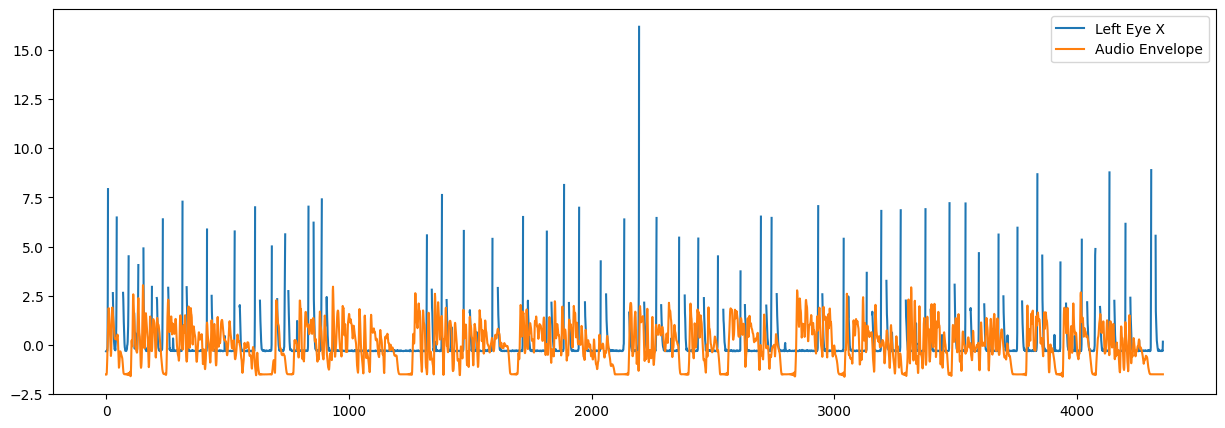

In [131]:
from scipy.stats import zscore
import matplotlib.pyplot as plt
currentGazeData = gazeData[124]

plt.figure(figsize=(15,5))
x = np.asarray(currentGazeData['LeftX'])
y = np.asarray(currentGazeData['LeftY'])

dx = np.diff(x)
dy = np.diff(y)

delta_pos = np.sqrt(dx**2 + dy**2)

# żeby zachować długość sygnału
delta_pos = np.concatenate([[0], delta_pos])

plt.plot(zscore(delta_pos,nan_policy='omit'), label='Left Eye X')
plt.plot(zscore(currentGazeData['AudioEnvelope'],nan_policy='omit'), label='Audio Envelope')
plt.legend()

In [132]:
### Gut the trials to 10s BEFORE the MW Report 

allGazeData = pd.concat(gazeData, ignore_index=True)

end = allGazeData.groupby(['DS','trialNum'])['TimePoint'].transform('max') # Get the Maximum out of our data - so a maximum sample of our index

if trialLength == "All":
    allGazeData = allGazeData[ allGazeData['TimePoint'] >= end - 40000] # All Timepoints that are simpoly put LARGER than max-10s

else:
    allGazeData = allGazeData[ allGazeData['TimePoint'] >= end - 10000] # All Timepoints that are simpoly put LARGER than max-10s

### Resampling to 50Hz:
allGazeData = allGazeData.iloc[::2].reset_index(drop=True)

allGazeData.to_csv(os.path.join(workingDir,ExpName,currentANalysisName,f'allGazeData_{trialLength}.csv'), index=False)

In [133]:
gazeData

[       TimePoint  LeftX  LeftY    LeftPupil  RightX  RightY   RightPupil  \
 65           0.0  989.4  511.6  4653.600000   954.7   497.1  4578.000000   
 70          10.0  991.2  514.7  4657.753424   955.9   501.9  4581.333333   
 75          20.0  994.3  516.9  4661.350788   958.9   502.7  4583.714286   
 80          30.0  993.8  513.4  4664.411878   958.9   502.6  4586.250000   
 85          40.0  990.5  514.3  4667.661792   959.3   500.1  4592.222222   
 ...          ...    ...    ...          ...     ...     ...          ...   
 21330    42530.0  953.5  535.1  5410.699224   959.4   550.2  5338.200000   
 21335    42540.0  952.7  534.6  5405.718600   956.7   552.6  5336.555556   
 21340    42550.0  954.1  534.6  5401.470754   960.7   551.9  5333.875000   
 21345    42560.0  952.8  536.0  5397.536300   959.1   552.1  5331.000000   
 21350    42570.0  954.5  538.1  5393.666667   960.6   556.6  5329.666667   
 
              DS  trialNum  MW_Estimate Tracking  SaccadeEnv  AudioEnvelop

In [134]:
### Get NaN adjacent Indicies and CUT THEM OUT
# Additionaly - create a mask showing WHICH SAMPLES SHOULD NOT BE INCLUDED In TRF Learning

nan_mask = allGazeData['LeftPupil'].isna()

lag = 50
cluster_edges = nan_mask & ~nan_mask.shift(1, fill_value=False) # Shifting signal down one - if there is a mismatch between those - this is the cluster boundary 
expand_mask = cluster_edges.rolling(2*lag+1, center=True).max() # For every Cluster boundary - expand it by lag on both sides

trueMask = ~(nan_mask | expand_mask)

allGazeData['nanMask'] = nan_mask;
allGazeData['nanEnvMask'] = trueMask;



### True Data Counts:
print(f"True Data Rate:{sum(trueMask)/len(allGazeData['RightPupil']):.2%} ({sum(trueMask)} out of {len(allGazeData['RightPupil'])} samples)")


### Gut the nanMask Data

allGazeDataCut = allGazeData; # DO NOT CUT OUT THE DATA BECAUSE TRF FUNCTION SHOULD HANDLE IT INTERNALLY 
allGazeDataCut

True Data Rate:95.52% (2369590 out of 2480620 samples)


,TimePoint,LeftX,LeftY,LeftPupil,RightX,RightY,RightPupil,DS,trialNum,MW_Estimate,...,SaccadeEnv,AudioEnvelope,NanMaskVel,Y,X,GazeDifference,GazeVelocity,BlinkEnv,nanMask,nanEnvMask
0,2570.0,972.6,559.9,5932.797719,962.4,570.3,5801.400000,AGKO2706,0,33.0,...,0.0,10243.232312,True,559.900000,972.600000,23.553556,3.488553,0.0,False,True
1,2590.0,974.1,556.5,5959.267368,965.1,574.7,5821.700000,AGKO2706,0,33.0,...,0.0,7076.538192,True,556.500000,974.100000,21.703917,1.910497,0.0,False,True
2,2610.0,973.2,551.6,5983.180648,969.8,568.5,5838.700000,AGKO2706,0,33.0,...,0.0,6038.038044,True,551.600000,973.200000,17.572706,3.956008,0.0,False,True
3,2630.0,972.3,553.0,6002.770737,971.6,570.0,5847.900000,AGKO2706,0,33.0,...,0.0,14717.362996,True,553.000000,972.300000,17.896648,1.104536,0.0,False,True
4,2650.0,970.7,550.0,6014.574573,972.7,573.8,5847.000000,AGKO2706,0,33.0,...,0.0,23884.902089,True,550.000000,970.700000,14.645477,3.551056,0.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2480615,49390.0,1023.6,554.9,4061.104459,973.8,526.3,3625.500000,ZURY1007,39,2.0,...,0.0,7713.904387,True,552.945454,1022.044255,63.402917,5.124556,0.0,False,True
2480616,49410.0,1025.8,550.0,4061.052323,974.0,530.4,3624.400000,ZURY1007,39,2.0,...,0.0,8368.635534,True,552.504231,1025.023186,66.258332,5.847855,0.0,False,True
2480617,49430.0,1025.2,553.3,4063.418674,974.8,530.3,3624.800000,ZURY1007,39,2.0,...,0.0,8343.062579,True,553.103807,1024.007159,65.356141,3.589214,0.0,False,True
2480618,49450.0,1025.6,551.4,4065.747766,977.6,535.7,3626.666667,ZURY1007,39,2.0,...,0.0,7621.214203,True,553.223458,1027.247519,68.544943,5.375126,0.0,False,True


In [135]:
import numpy as np

def build_lagged_matrix(x, lags):
    """
    x : (T,) stimulus
    lags : array of lags in samples (np.arange)
    returns X : (T, len(lags))
    """
    T = len(x)
    X = np.zeros((T, len(lags)))

    for i, lag in enumerate(lags):
        if lag == 0:
            X[:, i] = x
        else:
            X[lag:, i] = x[:-lag]

    return X

In [136]:
import time
import numpy as np
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr,spearmanr
from joblib import Parallel, delayed
import numpy as np
import time
fs = 50
max_lag_ms = 500
alpha = 0.05
lags = np.arange(0, int(max_lag_ms * fs / 1000))
n_perm = 100

def l1_normalize_keep_nan(arr):
    """
    Normalizuje tablicę względem ℓ1 normy tylko na elementach nie-NaN.
    NaNy pozostają w miejscu.
    """
    mask = ~np.isnan(arr)
    norm = np.sum(np.abs(arr[mask])) + 1e-8  # ℓ1 norm tylko po nie-NaN
    arr_out = arr.copy()
    arr_out[mask] = arr[mask] / norm
    return arr_out


def zscore_nan(x):
    """Prosty Zscore beznanowy"""
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    return (x - mu) / (sd + 1e-8)

import numpy as np
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr
from scipy.interpolate import interp1d
import statsmodels.api as sm


trials = list(allGazeDataCut.groupby(['DS','trialNum']))

column = dfAnalysisName;
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr


from scipy.signal import firwin, filtfilt


ddda = pd.concat(pupilMWs_all);
ddda.columns = ['DS','trialNum','MW Estimate','Tracking']

def TRFsingle(y_colName,x_colName,df_train,df_test,fs=1000,min_lags_ms=-100,max_lag_ms=500,alpha=0.05):
    """
        This function creates and computes TRF based on some DF Data 
    """
    lags = np.arange(int(min_lags_ms * fs / 1000), int(max_lag_ms * fs / 1000))

    # ℓ1-normalizacja zscore Not NAN
    x_train = zscore_nan(df_train[x_colName].values)
    y_train = zscore_nan(df_train[y_colName].values)

    x_test  = zscore_nan(df_test[x_colName].values)
    y_test  = zscore_nan(df_test[y_colName].values)

        # --- build lag matrices ---
    X_train = build_lagged_matrix(x_train, lags)
    X_test  = build_lagged_matrix(x_test,  lags)

        # --- ridge ---
    # model = Ridge(alpha=alpha, fit_intercept=True)
    # model.fit(X_train, y_train)

    # Dodaj intercept
    X_train_sm = sm.add_constant(X_train, has_constant='add')
    X_test_sm  = sm.add_constant(X_test, has_constant='add')

    # fit OLS z automatycznym ignorowaniem NaN w X lub y
    model_sm = sm.OLS(y_train, X_train_sm, missing='drop').fit_regularized(L1_wt=0.0, alpha=0.001)

    # predykcja

    y_pred = model_sm.predict(X_test_sm)

    # --- score --- ONLY ON NOT NANS
    mask_valid = ~np.isnan(y_test) & ~np.isnan(y_pred)
    r, _ = spearmanr(y_test[mask_valid], y_pred[mask_valid])
    z = np.arctanh(r)

    return r,z


def compute_null(p,blocks,df_train,df_test,column='LeftPupil'):
    rng = np.random.default_rng(seed=counter*1000 + p)
    rng.shuffle(blocks)
    y_train_shuffled = np.concatenate(blocks)
    df_train_shuffled = df_train.copy()
    df_train_shuffled[column] = y_train_shuffled
    _, z_null = TRFsingle(column,'AudioEnvelope',df_train_shuffled, df_test, fs=50, max_lag_ms=500, alpha=0.001)
    return z_null


resultsDf = ddda

for i,analysisName in enumerate(dfAnalysisList):
    resultsCurr = []
    totalTime= 0
    print(f"==== Analysis Current: {analysisName} ====")
    for counter, ((subj, trial), df_test) in enumerate(trials):

        start_trial = time.time()
        #print(f"Processing: {subj} - Trial {trial}")

        ### ==== Correlationls ===== (More Prune Would be do compute Correlation for EACH TRIAL)
        currSubjData = allGazeDataCut[(allGazeDataCut['DS'] == subj)  & (allGazeDataCut['trialNum']==trial)]

        mask_Corrs = ~allGazeDataCut[(allGazeDataCut['DS'] == subj) & (allGazeDataCut['trialNum']==trial)][analysisName].isna()
        r_corr, _ = spearmanr(currSubjData['AudioEnvelope'].loc[mask_Corrs], currSubjData[analysisName].loc[mask_Corrs])
        z_corr = np.arctanh(r_corr)

        ### ==== Proper TRFs =====

        ## Get Simple Trains
        mask_train = ~((allGazeDataCut['DS']==subj) & (allGazeDataCut['trialNum']==trial))
        df_train = allGazeDataCut[mask_train]
        df_train = df_train[df_train['DS']==subj]

        if trialLength == "All":
            cutoff = 1500;
        else:
            cutoff = 300;

        if np.sum(df_test[analysisName].isna()) > 1500: ### On the rare occasion that we have All NaNs in our Subject
            resultsCurr.append({
                'DS': subj,
                'trialNum': trial,
                f'r_{analysisName}': np.nan,
                f'z_{analysisName}': np.nan,
                f'rcorr_{analysisName}':np.nan,
                f'zcorr_{analysisName}':np.nan

            })
        else:
            
            # --- TRF na oryginalnych danych ---
            r, z = TRFsingle(analysisName, 'AudioEnvelope', df_train, df_test, fs=fs, max_lag_ms=max_lag_ms, alpha=alpha)

        
            # # równoległe liczenie permutacji
            # blocks = [g.values for _, g in df_train.groupby(['DS','trialNum'], sort=False)[column]]
            # z_nulls = Parallel(n_jobs=8, backend='threading')(
            #     delayed(compute_null)(p,blocks,df_train,df_test) for p in range(n_perm)
            # )

            resultsCurr.append({
                'DS': subj,
                'trialNum': trial,
                f'r_{analysisName}': r,
                f'z_{analysisName}': z,
                f'rcorr_{analysisName}': r_corr,
                f'zcorr_{analysisName}': z_corr

                # 'z_null_mean': np.mean(z_nulls),
                # 'z_null_std': np.std(z_nulls),
                # 'null_pval':  np.mean(np.abs(z_nulls) >= np.abs(z)),
                # 'null_zsc': ( np.abs(z) - np.mean(np.abs(z_nulls))) / np.std(np.abs(z_nulls))
            })

        elapsed = time.time() - start_trial
        totalTime = totalTime +elapsed
        print(f"\r    Trial {counter+1}/{len(trials)} done in {totalTime:.2f}s", end="", flush=True)

    resultsTestingCurr = pd.merge(pd.DataFrame(resultsCurr), ddda, on=['DS','trialNum'], how='left')
    resultsTestingStats = resultsTestingCurr.groupby(['Tracking'])[f'z_{analysisName}'].agg(['mean','std'])

    resultsDf = pd.merge(resultsDf,resultsTestingCurr,on= ['DS','trialNum','MW Estimate','Tracking'], how='left')
    
    print("\n               Cued     UnCued ")
    print(f"    TRFmean:   {resultsTestingStats['mean'].iloc[0]:0.3f}   {resultsTestingStats['mean'].iloc[1]:0.3f}")
    print(f"    TRFstd:    {resultsTestingStats['std'].iloc[0]:0.3f}   {resultsTestingStats['std'].iloc[1]:0.3f}")
    print(f"    Corrmean:  {resultsTestingStats['mean'].iloc[0]:0.3f}   {resultsTestingStats['mean'].iloc[1]:0.3f}")
    print(f"    Corrstd:   {resultsTestingStats['std'].iloc[0]:0.3f}   {resultsTestingStats['std'].iloc[1]:0.3f}")


        
 

==== Analysis Current: GazeDifference ====
    Trial 1240/1240 done in 1033.29s
               Cued     UnCued 
    TRFmean:   0.018   0.012
    TRFstd:    0.068   0.068
    Corrmean:  0.018   0.012
    Corrstd:   0.068   0.068
==== Analysis Current: GazeVelocity ====
    Trial 1240/1240 done in 1197.44s
               Cued     UnCued 
    TRFmean:   0.013   0.012
    TRFstd:    0.042   0.037
    Corrmean:  0.013   0.012
    Corrstd:   0.042   0.037
==== Analysis Current: LeftPupil ====
    Trial 1240/1240 done in 1190.97s
               Cued     UnCued 
    TRFmean:   0.027   0.023
    TRFstd:    0.089   0.090
    Corrmean:  0.027   0.023
    Corrstd:   0.089   0.090
==== Analysis Current: X ====
    Trial 1240/1240 done in 963.65s
               Cued     UnCued 
    TRFmean:   0.008   0.004
    TRFstd:    0.071   0.071
    Corrmean:  0.008   0.004
    Corrstd:   0.071   0.071
==== Analysis Current: Y ====
    Trial 1240/1240 done in 926.49s
               Cued     UnCued 
    TRFmean

In [137]:
resultsDf

,DS,trialNum,MW Estimate,Tracking,r_GazeDifference,z_GazeDifference,rcorr_GazeDifference,zcorr_GazeDifference,r_GazeVelocity,z_GazeVelocity,...,rcorr_LeftPupil,zcorr_LeftPupil,r_X,z_X,rcorr_X,zcorr_X,r_Y,z_Y,rcorr_Y,zcorr_Y
0,AGKO2706,0,33.0,TRACKED,0.127989,0.128695,-0.104077,-0.104456,-0.034414,-0.034428,...,0.030087,0.030096,0.079566,0.079735,0.039729,0.039750,-0.058879,-0.058947,0.029802,0.029810
1,AGKO2706,1,42.0,UNTRACKED,-0.140174,-0.141103,0.138595,0.139493,-0.020650,-0.020653,...,-0.186258,-0.188458,0.172778,0.174528,0.133780,0.134587,-0.077295,-0.077450,0.102237,0.102596
2,AGKO2706,2,26.0,TRACKED,0.064031,0.064119,-0.088568,-0.088801,0.023558,0.023562,...,0.056202,0.056261,-0.003904,-0.003904,-0.027043,-0.027050,0.039640,0.039660,-0.036199,-0.036215
3,AGKO2706,3,36.0,UNTRACKED,0.057453,0.057516,-0.077762,-0.077919,-0.014197,-0.014198,...,0.032457,0.032468,-0.056101,-0.056160,-0.070937,-0.071056,0.092098,0.092360,-0.124619,-0.125270
4,AGKO2706,4,18.0,TRACKED,0.007855,0.007855,-0.014897,-0.014898,0.036891,0.036908,...,-0.040574,-0.040596,0.016332,0.016334,-0.032199,-0.032210,0.035477,0.035491,-0.009474,-0.009474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1235,ZURY1007,35,66.0,UNTRACKED,0.136876,0.137741,0.061493,0.061571,0.058455,0.058522,...,-0.001537,-0.001537,-0.076174,-0.076322,0.050676,0.050719,-0.044251,-0.044280,-0.041509,-0.041533
1236,ZURY1007,36,32.0,TRACKED,-0.025803,-0.025809,0.010684,0.010685,0.020074,0.020076,...,-0.036878,-0.036895,0.011820,0.011820,-0.006372,-0.006372,-0.021645,-0.021648,-0.015667,-0.015668
1237,ZURY1007,37,53.0,UNTRACKED,0.039029,0.039049,-0.007268,-0.007268,0.017841,0.017843,...,0.006443,0.006443,-0.015769,-0.015770,0.000282,0.000282,0.050882,0.050926,0.001923,0.001923
1238,ZURY1007,38,42.0,TRACKED,-0.024501,-0.024506,-0.089833,-0.090075,-0.070460,-0.070577,...,-0.085671,-0.085881,0.048169,0.048207,-0.091059,-0.091312,-0.010098,-0.010099,-0.058935,-0.059003


In [138]:
resultsDf.to_excel(os.path.join(os.path.join(workingDir,ExpName,currentANalysisName,'summary'),f"TRF_data_{trialLength}.xlsx"))


In [139]:
resultsTestingStats = resultsDf.groupby(['Tracking'])[['r_GazeVelocity','z_GazeVelocity',	'rcorr_GazeVelocity',	'r_LeftPupil',	'z_LeftPupil',	'rcorr_LeftPupil',	'r_X',	'z_X',	'rcorr_X',	'r_Y',	'z_Y',	'rcorr_Y']].agg(['mean','std'])
resultsTestingStats

r_GazeVelocity           z_GazeVelocity            \
                    mean       std           mean       std   
Tracking                                                      
TRACKED         0.012792  0.042087       0.012839  0.042279   
UNTRACKED       0.012195  0.037358       0.012225  0.037460   

          rcorr_GazeVelocity           r_LeftPupil           z_LeftPupil  \
                        mean       std        mean       std        mean   
Tracking                                                                   
TRACKED             0.010329  0.043419    0.026970  0.087798    0.027175   
UNTRACKED           0.009727  0.039837    0.022501  0.088928    0.022647   

                     ...       z_X             rcorr_X                 r_Y  \
                std  ...      mean       std      mean       std      mean   
Tracking             ...                                                     
TRACKED    0.088796  ...  0.008489  0.071146  0.005973  0.064771  0.015374   
UNTRACKED  0.089718  ...  0.004465  0.070919  0.005260  0.064501  0.014321   

                          z_Y             rcorr_Y            
                std      mean       std      mean       std  
Tracking                                                     
TRACKED    0.064569  0.015489  0.065026  0.014567  0.064429  
UNTRACKED  0.065766  0.014407  0.066150  0.010723  0.065475  

[2 rows x 24 columns]

In [140]:
resultsTestingStats.columns

MultiIndex([(    'r_GazeVelocity', 'mean'),
            (    'r_GazeVelocity',  'std'),
            (    'z_GazeVelocity', 'mean'),
            (    'z_GazeVelocity',  'std'),
            ('rcorr_GazeVelocity', 'mean'),
            ('rcorr_GazeVelocity',  'std'),
            (       'r_LeftPupil', 'mean'),
            (       'r_LeftPupil',  'std'),
            (       'z_LeftPupil', 'mean'),
            (       'z_LeftPupil',  'std'),
            (   'rcorr_LeftPupil', 'mean'),
            (   'rcorr_LeftPupil',  'std'),
            (               'r_X', 'mean'),
            (               'r_X',  'std'),
            (               'z_X', 'mean'),
            (               'z_X',  'std'),
            (           'rcorr_X', 'mean'),
            (           'rcorr_X',  'std'),
            (               'r_Y', 'mean'),
            (               'r_Y',  'std'),
            (               'z_Y', 'mean'),
            (               'z_Y',  'std'),
            (           'rcorr_Y

In [141]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
from matplotlib.backends.backend_pdf import PdfPages

models = []

savePathFeatures = os.path.join(workingDir,ExpName,currentANalysisName,'summary');

pdf_path = os.path.join(savePathFeatures, "TRF_Tr.pdf")
pdfs_MW_Tr = PdfPages(pdf_path)
out_path = os.path.join(savePathFeatures, "mixedlm_fixed_effects_TRF.xlsx")

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'Tracking[T.UNTRACKED]', 'trialNum']


from analysisFunctions import plotTrialTrack


for i, ind in enumerate((list(resultsDf.drop(['DS','trialNum','Tracking','MW Estimate'],axis=1).columns.get_level_values(0)))):
    print("\n\n=============================================================")
    print(f"======== TRF Test for Tracking vs {ind} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = resultsDf[['trialNum','DS','Tracking',ind]]
    currentDf.columns = [ 'trialNum','DS', 'Tracking','TRF']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=[ 'Tracking', 'trialNum','TRF'])  # Drop rows with NaN
    currentDf = currentDf[currentDf['TRF'] - currentDf['TRF'].mean() <3*currentDf['TRF'].std()] #Rule out outliers by 3 sigma rule:


    # Fit the mixed effects model

    m = smf.mixedlm("TRF ~ Tracking+trialNum ", data=currentDf,
                groups="DS",          # random intercept
                #re_formula="~Tracking",         # adds random slope
    ).fit();

    print(m.summary())   



    # ---- collect fixed-effect stats into a tiny table ----

    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"MW_Estimate vs {ind}"
    stats_tables[analysis_name] = tbl
    


    fig, ax = plt.subplots(figsize=(14, 8))
    plotTrialTrack(m,ind,resultsDf,ax,titl=f"Tracked vs Untracked : {ind} + Envelope (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})" )


    pdfs_MW_Tr.savefig(fig)
    plt.close(fig)

pdfs_MW_Tr.close()
all_stats_TRF_Tr = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_TRF_Tr.index.names or []) else -1
all_stats_TRF_Tr = all_stats_TRF_Tr[~all_stats_TRF_Tr.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_TRF_Tr



======== TRF Test for Tracking vs r_GazeDifference =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\eelbrain_env\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    TRF      
No. Observations:    1230       Method:                REML     
No. Groups:          31         Scale:                 0.0039   
Min. group size:     35         Log-Likelihood:        1626.6227
Max. group size:     40         Converged:             Yes      
Mean group size:     39.7                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.012    0.005  2.326 0.020  0.002  0.023
Tracking[T.UNTRACKED] -0.005    0.004 -1.336 0.182 -0.012  0.002
trialNum               0.000    0.000  1.231 0.218 -0.000  0.000
DS Var                 0.000    0.002                           



======== TRF Test for Tracking vs z_GazeDifference =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\eelbrain_env\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    TRF      
No. Observations:    1229       Method:                REML     
No. Groups:          31         Scale:                 0.0039   
Min. group size:     34         Log-Likelihood:        1620.3097
Max. group size:     40         Converged:             Yes      
Mean group size:     39.6                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.013    0.005  2.367 0.018  0.002  0.023
Tracking[T.UNTRACKED] -0.005    0.004 -1.275 0.202 -0.012  0.002
trialNum               0.000    0.000  1.120 0.263 -0.000  0.000
DS Var                 0.000    0.002                           



======== TRF Test for Tracking vs rcorr_GazeDifference =======



...

c:\Users\barak\Documents\GitHub\startegicMW_lite\eelbrain_env\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    TRF      
No. Observations:    1234       Method:                REML     
No. Groups:          31         Scale:                 0.0039   
Min. group size:     38         Log-Likelihood:        1640.7644
Max. group size:     40         Converged:             Yes      
Mean group size:     39.8                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.012    0.005  2.469 0.014  0.002  0.021
Tracking[T.UNTRACKED] -0.004    0.004 -1.070 0.285 -0.011  0.003
trialNum               0.000    0.000  0.776 0.437 -0.000  0.000
DS Var                 0.000    0.001                           



======== TRF Test for Tracking vs zcorr_Y =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\eelbrain_env\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    TRF      
No. Observations:    1234       Method:                REML     
No. Groups:          31         Scale:                 0.0039   
Min. group size:     38         Log-Likelihood:        1635.9906
Max. group size:     40         Converged:             Yes      
Mean group size:     39.8                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.012    0.005  2.467 0.014  0.002  0.021
Tracking[T.UNTRACKED] -0.004    0.004 -1.073 0.283 -0.011  0.003
trialNum               0.000    0.000  0.781 0.435 -0.000  0.000
DS Var                 0.000    0.001                           



Coef         z  \
analysis                            stat                                        
MW_Estimate vs r_GazeDifference     Tracking[T.UNTRACKED] -0.004750 -1.335837   
                                    trialNum               0.000190  1.230600   
MW_Estimate vs z_GazeDifference     Tracking[T.UNTRACKED] -0.004555 -1.274578   
                                    trialNum               0.000174  1.119519   
MW_Estimate vs rcorr_GazeDifference Tracking[T.UNTRACKED] -0.004926 -1.363843   
                                    trialNum              -0.000104 -0.662170   
MW_Estimate vs zcorr_GazeDifference Tracking[T.UNTRACKED] -0.004623 -1.279142   
                                    trialNum              -0.000113 -0.722770   
MW_Estimate vs r_GazeVelocity       Tracking[T.UNTRACKED]  0.000059  0.030764   
                                    trialNum               0.000106  1.271174   
MW_Estimate vs z_GazeVelocity       Tracking[T.UNTRACKED]  0.000058  0.030195   
                                    trialNum               0.000106  1.271479   
MW_Estimate vs rcorr_GazeVelocity   Tracking[T.UNTRACKED] -0.000476 -0.222080   
                                    trialNum               0.000135  1.456977   
MW_Estimate vs zcorr_GazeVelocity   Tracking[T.UNTRACKED] -0.000480 -0.223631   
                                    trialNum               0.000136  1.458641   
MW_Estimate vs r_LeftPupil          Tracking[T.UNTRACKED] -0.003064 -0.626736   
                                    trialNum               0.000254  1.194726   
MW_Estimate vs z_LeftPupil          Tracking[T.UNTRACKED] -0.003068 -0.621650   
                                    trialNum               0.000250  1.168617   
MW_Estimate vs rcorr_LeftPupil      Tracking[T.UNTRACKED]  0.001642  0.468481   
                                    trialNum              -0.000425 -2.781070   
MW_Estimate vs zcorr_LeftPupil      Tracking[T.UNTRACKED]  0.001654  0.469815   
                                    trialNum              -0.000427 -2.782663   
MW_Estimate vs r_X                  Tracking[T.UNTRACKED] -0.003601 -0.940523   
                                    trialNum              -0.000175 -1.052153   
MW_Estimate vs z_X                  Tracking[T.UNTRACKED] -0.003986 -1.037532   
                                    trialNum              -0.000188 -1.127615   
MW_Estimate vs rcorr_X              Tracking[T.UNTRACKED] -0.000453 -0.126895   
                                    trialNum               0.000025  0.158411   
MW_Estimate vs zcorr_X              Tracking[T.UNTRACKED] -0.000466 -0.130043   
                                    trialNum               0.000023  0.145071   
MW_Estimate vs r_Y                  Tracking[T.UNTRACKED] -0.000037 -0.010870   
                                    trialNum               0.000094  0.638371   
MW_Estimate vs z_Y                  Tracking[T.UNTRACKED]  0.000260  0.076596   
                                    trialNum               0.000103  0.700031   
MW_Estimate vs rcorr_Y              Tracking[T.UNTRACKED] -0.003796 -1.070160   
                                    trialNum               0.000119  0.776462   
MW_Estimate vs zcorr_Y              Tracking[T.UNTRACKED] -0.003822 -1.073475   
                                    trialNum               0.000121  0.781435   

                                                                  P       Cf1  \
analysis                            stat                                        
MW_Estimate vs r_GazeDifference     Tracking[T.UNTRACKED]  0.181603 -0.011720   
                                    trialNum               0.218473 -0.000113   
MW_Estimate vs z_GazeDifference     Tracking[T.UNTRACKED]  0.202459 -0.011559   
                                    trialNum               0.262919 -0.000131   
MW_Estimate vs rcorr_GazeDifference Tracking[T.UNTRACKED]  0.172617 -0.012005   
                                    trialNum               0.507862 -0.000411   
MW_Estimate 



======== TRF Test for Tracking vs r_GazeDifference =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\eelbrain_env\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: TRF      
No. Observations: 1230    Method:             REML     
No. Groups:       31      Scale:              0.0039   
Min. group size:  35      Log-Likelihood:     1626.0766
Max. group size:  40      Converged:          Yes      
Mean group size:  39.7                                 
-------------------------------------------------------
               Coef. Std.Err.   z   P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept      0.011    0.005 2.148 0.032  0.001  0.021
MW_est_norm    0.003    0.002 1.419 0.156 -0.001  0.006
trialNum       0.000    0.000 0.931 0.352 -0.000  0.000
DS Var         0.000    0.002                          



======== TRF Test for Tracking vs z_GazeDifference =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\eelbrain_env\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: TRF      
No. Observations: 1229    Method:             REML     
No. Groups:       31      Scale:              0.0039   
Min. group size:  34      Log-Likelihood:     1619.7572
Max. group size:  40      Converged:          Yes      
Mean group size:  39.6                                 
-------------------------------------------------------
               Coef. Std.Err.   z   P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept      0.011    0.005 2.205 0.027  0.001  0.021
MW_est_norm    0.003    0.002 1.357 0.175 -0.001  0.006
trialNum       0.000    0.000 0.834 0.404 -0.000  0.000
DS Var         0.000    0.002                          



======== TRF Test for Tracking vs rcorr_GazeDifference =======



...

c:\Users\barak\Documents\GitHub\startegicMW_lite\eelbrain_env\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: TRF      
No. Observations: 1234    Method:             REML     
No. Groups:       31      Scale:              0.0039   
Min. group size:  38      Log-Likelihood:     1640.0169
Max. group size:  40      Converged:          Yes      
Mean group size:  39.8                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.009    0.004  2.076 0.038  0.001  0.018
MW_est_norm  -0.002    0.002 -0.985 0.324 -0.005  0.002
trialNum      0.000    0.000  0.948 0.343 -0.000  0.000
DS Var        0.000    0.001                           



======== TRF Test for Tracking vs zcorr_Y =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\eelbrain_env\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\analysisFunctions.py:1987: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 6))


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: TRF      
No. Observations: 1234    Method:             REML     
No. Groups:       31      Scale:              0.0039   
Min. group size:  38      Log-Likelihood:     1635.2375
Max. group size:  40      Converged:          Yes      
Mean group size:  39.8                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.009    0.004  2.073 0.038  0.000  0.018
MW_est_norm  -0.002    0.002 -0.983 0.325 -0.005  0.002
trialNum      0.000    0.000  0.952 0.341 -0.000  0.000
DS Var        0.000    0.001                           



Coef         z         P  \
analysis                            stat                                        
MW_Estimate vs r_GazeDifference     trialNum     0.000146  0.930972  0.351868   
                                    MW_est_norm  0.002606  1.419261  0.155823   
MW_Estimate vs z_GazeDifference     trialNum     0.000132  0.834339  0.404090   
                                    MW_est_norm  0.002504  1.357078  0.174757   
MW_Estimate vs rcorr_GazeDifference trialNum    -0.000101 -0.631492  0.527719   
                                    MW_est_norm -0.000237 -0.126431  0.899391   
MW_Estimate vs zcorr_GazeDifference trialNum    -0.000111 -0.694997  0.487057   
                                    MW_est_norm -0.000200 -0.107101  0.914709   
MW_Estimate vs r_GazeVelocity       trialNum     0.000117  1.385754  0.165822   
                                    MW_est_norm -0.000727 -0.737107  0.461057   
MW_Estimate vs z_GazeVelocity       trialNum     0.000117  1.385837  0.165797   
                                    MW_est_norm -0.000727 -0.735939  0.461768   
MW_Estimate vs rcorr_GazeVelocity   trialNum     0.000148  1.565625  0.117436   
                                    MW_est_norm -0.000793 -0.718066  0.472716   
MW_Estimate vs zcorr_GazeVelocity   trialNum     0.000148  1.567029  0.117108   
                                    MW_est_norm -0.000793 -0.716836  0.473475   
MW_Estimate vs r_LeftPupil          trialNum     0.000264  1.219119  0.222799   
                                    MW_est_norm -0.000646 -0.256098  0.797875   
MW_Estimate vs z_LeftPupil          trialNum     0.000260  1.192145  0.233204   
                                    MW_est_norm -0.000634 -0.248928  0.803416   
MW_Estimate vs rcorr_LeftPupil      trialNum    -0.000406 -2.611298  0.009020   
                                    MW_est_norm -0.001174 -0.648831  0.516448   
MW_Estimate vs zcorr_LeftPupil      trialNum    -0.000408 -2.613623  0.008959   
                                    MW_est_norm -0.001172 -0.644731  0.519101   
MW_Estimate vs r_X                  trialNum    -0.000222 -1.312896  0.189218   
                                    MW_est_norm  0.002916  1.475374  0.140112   
MW_Estimate vs z_X                  trialNum    -0.000234 -1.381643  0.167081   
                                    MW_est_norm  0.002879  1.451985  0.146506   
MW_Estimate vs rcorr_X              trialNum    -0.000002 -0.011106  0.991139   
                                    MW_est_norm  0.001625  0.881363  0.378121   
MW_Estimate vs zcorr_X              trialNum    -0.000004 -0.023790  0.981020   
                                    MW_est_norm  0.001629  0.879116  0.379338   
MW_Estimate vs r_Y                  trialNum     0.000122  0.816830  0.414025   
                                    MW_est_norm -0.001766 -1.013826  0.310666   
MW_Estimate vs z_Y                  trialNum     0.000130  0.869785  0.384418   
                                    MW_est_norm -0.001696 -0.971947  0.331077   
MW_Estimate vs rcorr_Y              trialNum     0.000149  0.947525  0.343371   
                                    MW_est_norm -0.001806 -0.985384  0.324435   
MW_Estimate vs zcorr_Y              trialNum     0.000150  0.952000  0.341097   
                                    MW_est_norm -0.001809 -0.983349  0.325436   

                                                      Cf1       Cf2  
analysis                            stat                             
MW_Estimate vs r_GazeDifference     trialNum    -0.000162  0.000455  
                                    MW_est_norm -0.000993  0.006205  
MW_Estimate vs z_GazeDifference     trialNum    -0.000178  0.000442  
                                    MW_est_norm -0.001112  0.006120  
MW_Estimate vs rcorr_GazeDifference trialNum    -0.000414  0.000212  
                                    MW_est_norm -0.003904  0.003431  
MW_Estimate vs zcorr_GazeDifference trialNum    -0.000424  0.000202  
                    

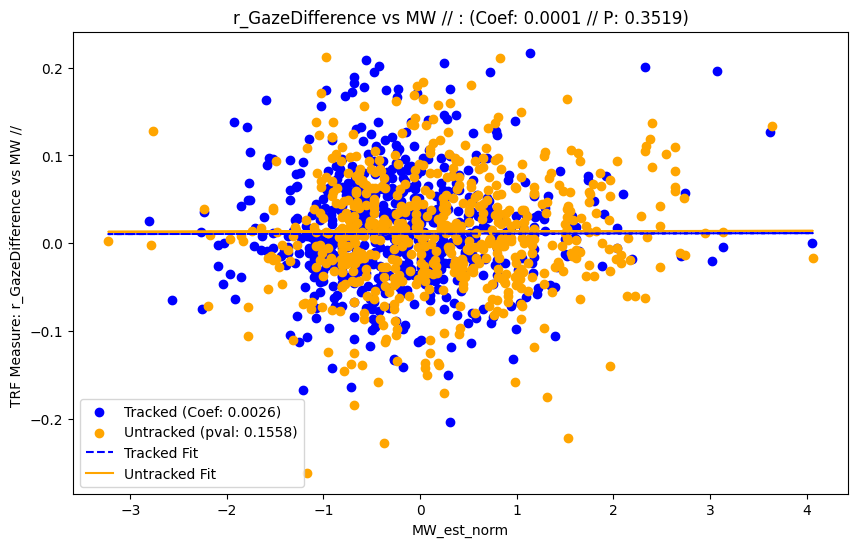

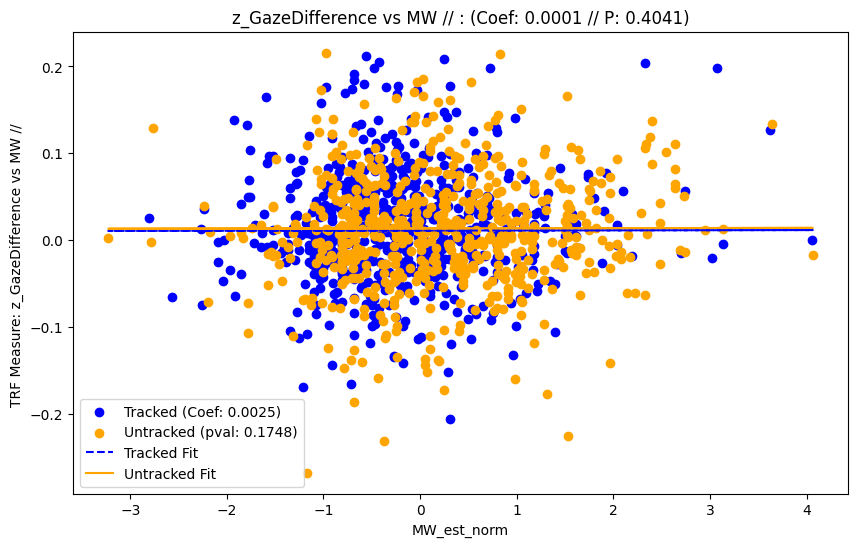

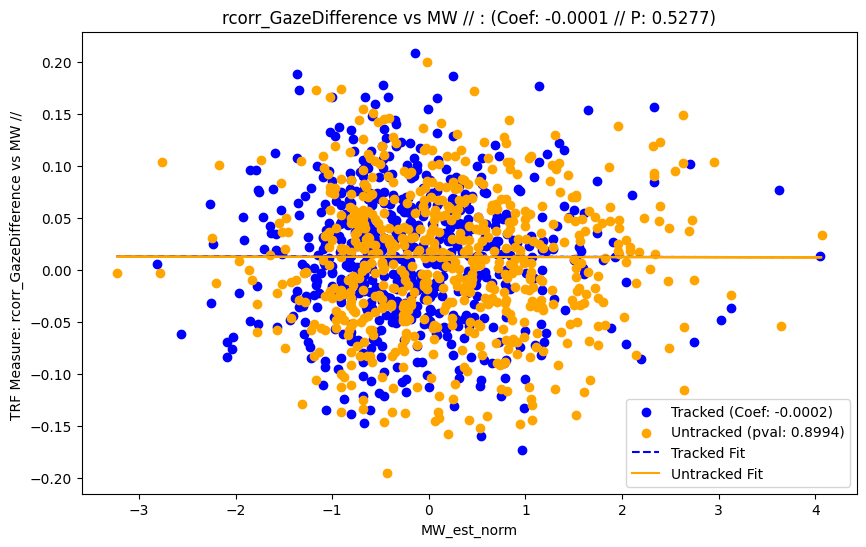

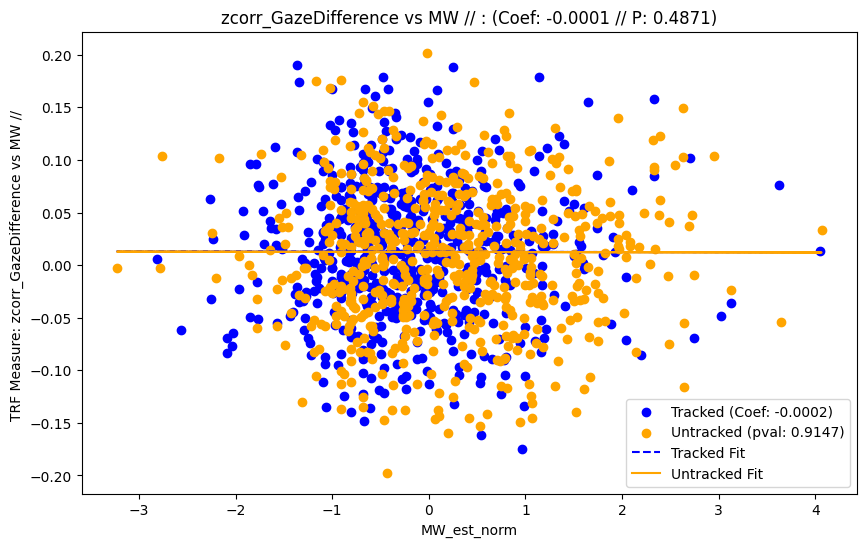

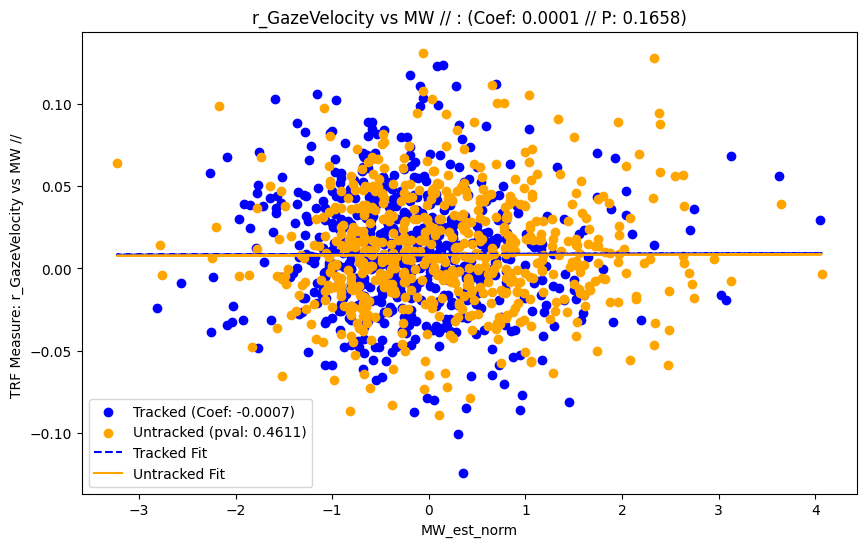

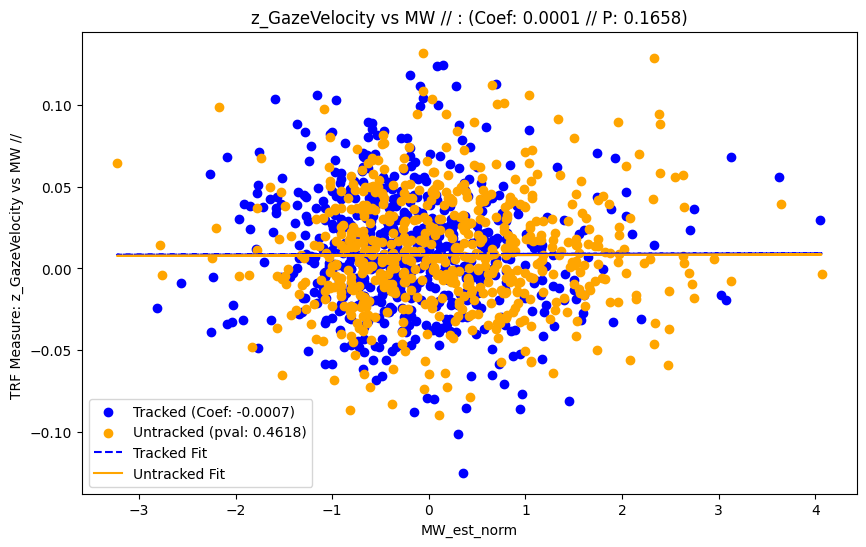

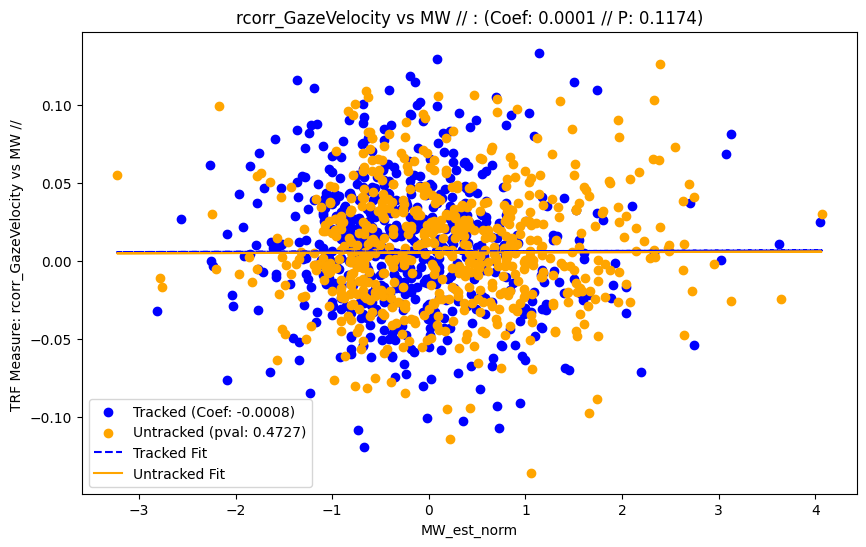

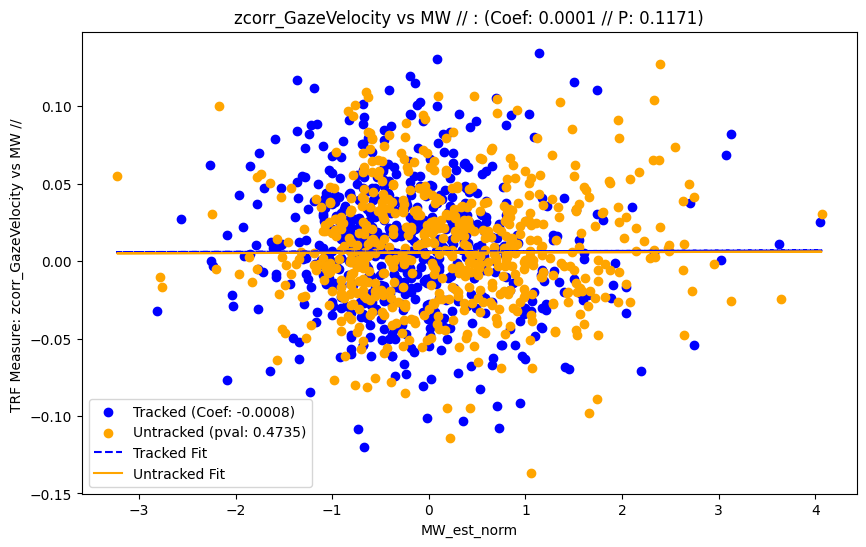

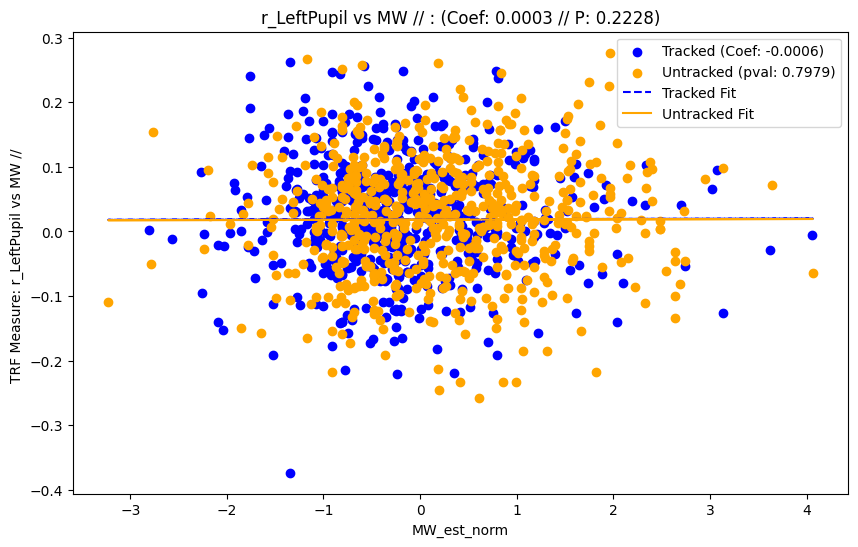

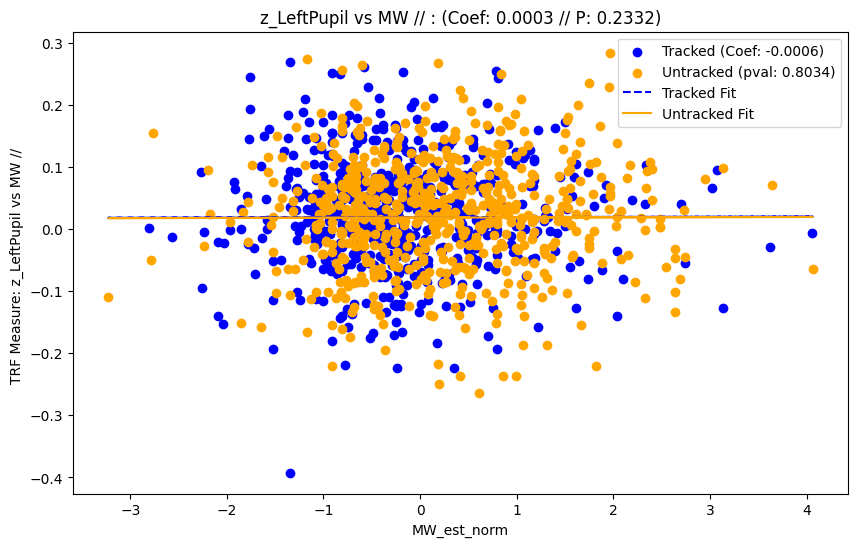

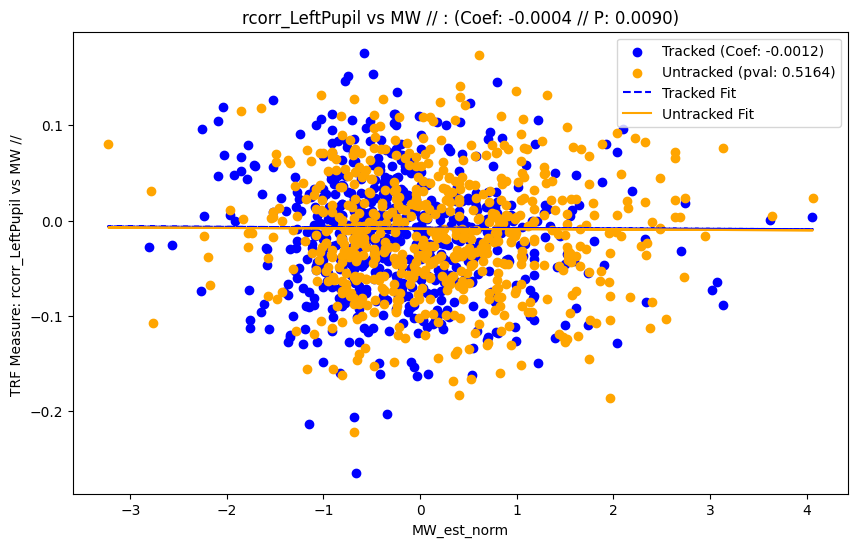

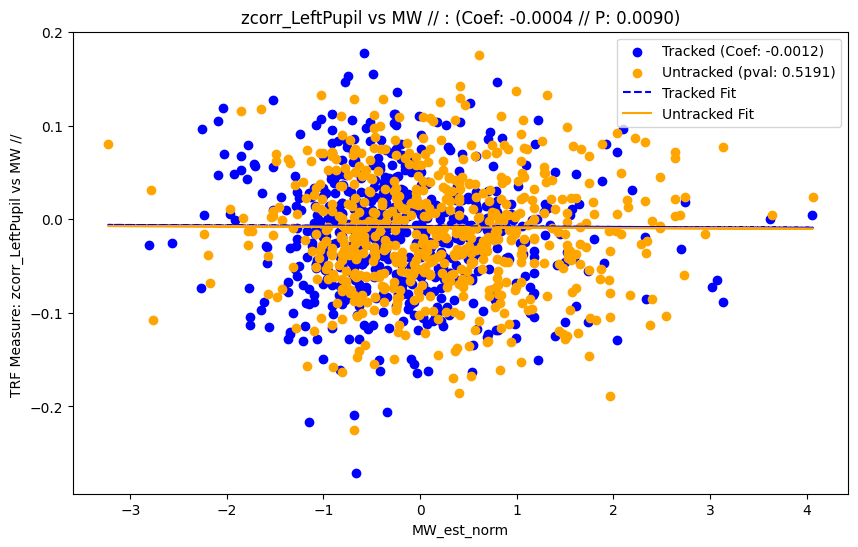

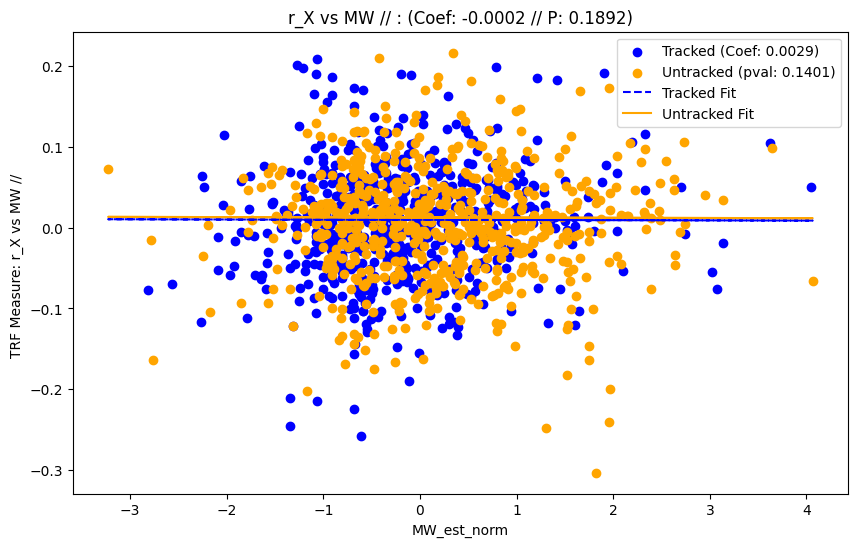

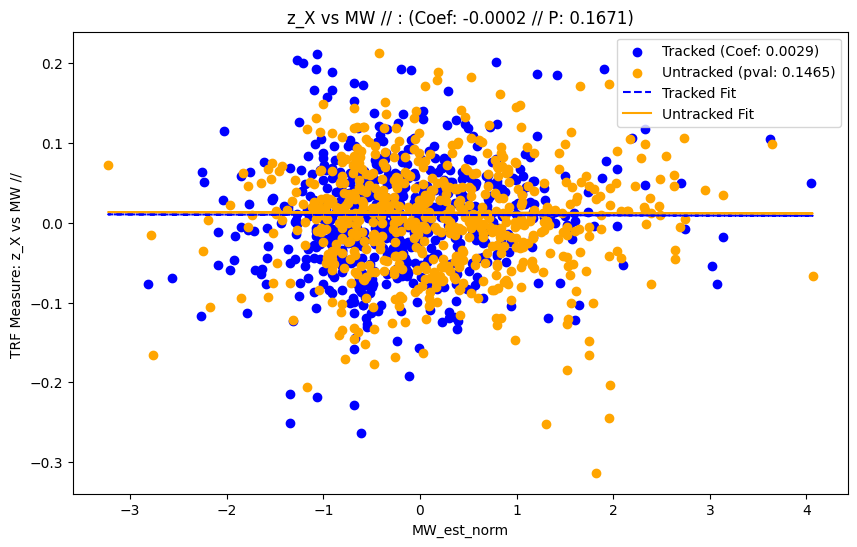

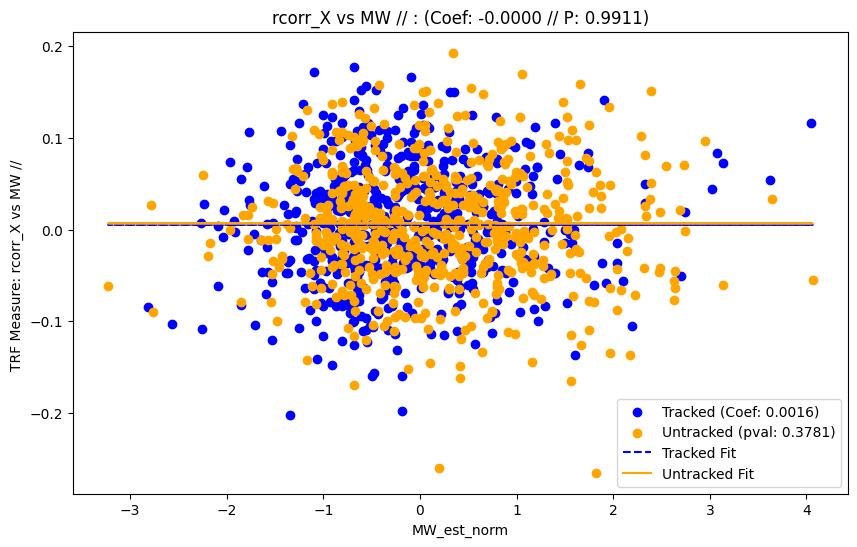

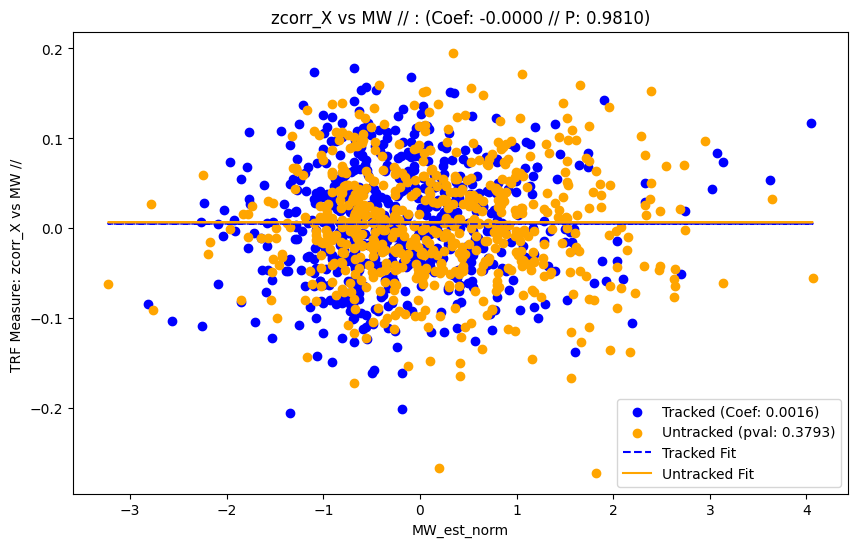

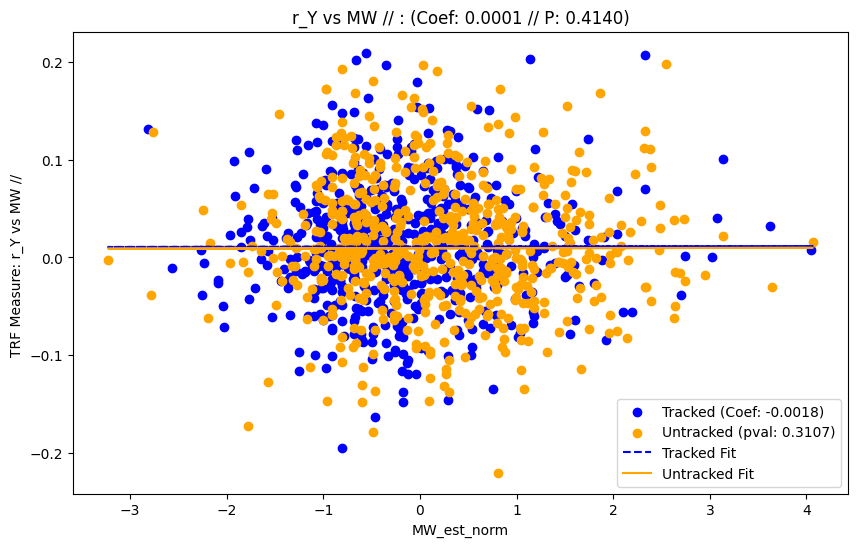

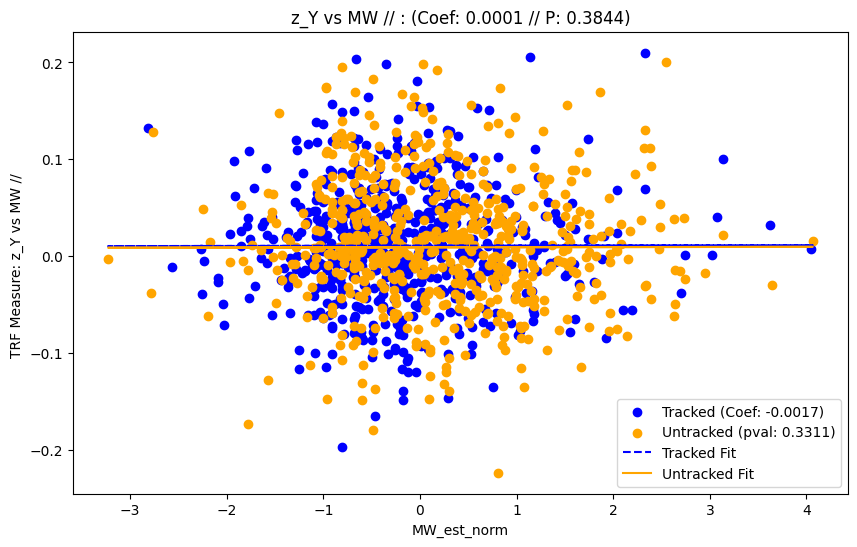

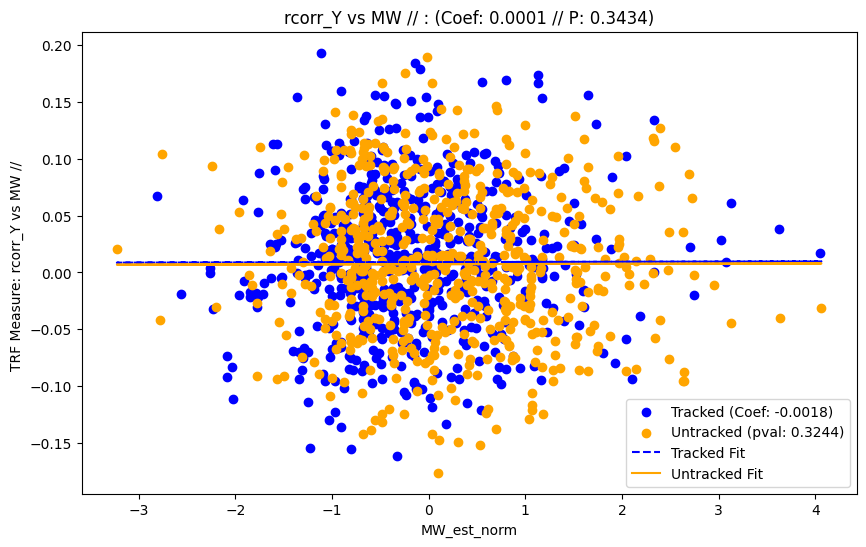

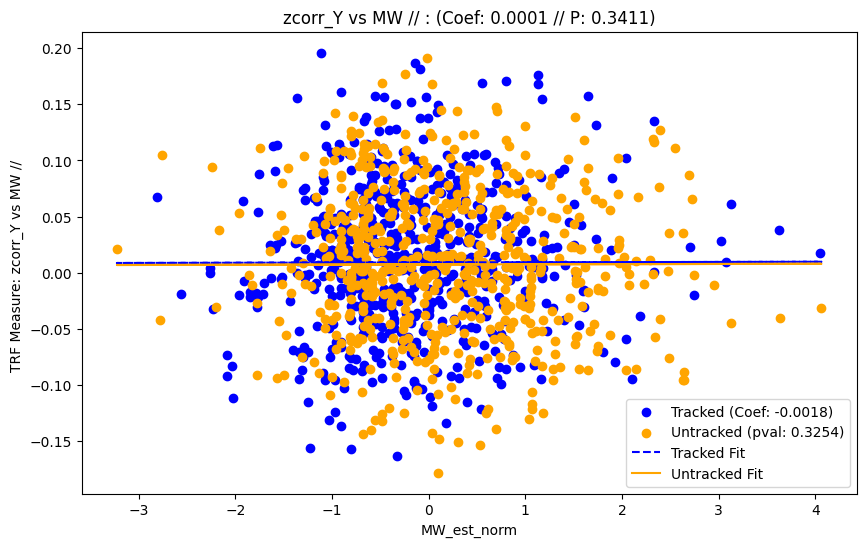

In [142]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
from matplotlib.backends.backend_pdf import PdfPages

models = []

savePathFeatures = os.path.join(workingDir,ExpName,currentANalysisName,'summary');

pdf_path = os.path.join(savePathFeatures, "TRF_MW.pdf")
pdfs_MW_Tr = PdfPages(pdf_path)
out_path = os.path.join(savePathFeatures, f"mixedlm_fixed_effects_TRF_{trialLength}.xlsx")

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'MW_Estimate', 'trialNum']

resultsDf['MW_est_norm'] = resultsDf.groupby('DS')['MW Estimate'].transform(
         lambda x: (x - x.mean()) / x.std() ) # Transforms a DataFrame BY GROUP but returns the original Data Frame! 
from analysisFunctions import plotTrialTrack


for i, ind in enumerate((list(resultsDf.drop(['DS','trialNum','Tracking','MW Estimate','MW_est_norm'],axis=1).columns.get_level_values(0)))):
    print("\n\n=============================================================")
    print(f"======== TRF Test for Tracking vs {ind} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = resultsDf[['trialNum','DS','MW_est_norm','Tracking',ind]]
    currentDf.columns = [ 'trialNum','DS', 'MW_est_norm', 'Tracking','TRF']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['MW_est_norm', 'Tracking', 'trialNum','TRF'])  # Drop rows with NaN
    currentDf = currentDf[currentDf['TRF'] - currentDf['TRF'].mean() <3*currentDf['TRF'].std()] #Rule out outliers by 3 sigma rule:


    # Fit the mixed effects model
    m = smf.mixedlm("TRF ~ MW_est_norm+trialNum ", data=currentDf,
                groups="DS",          # random intercept
                #re_formula="~Tracking",         # adds random slope
    ).fit();

    print(m.summary())   



    # ---- collect fixed-effect stats into a tiny table ----
    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T



    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"MW_Estimate vs {ind}"
    stats_tables[analysis_name] = tbl
    


    fig, ax = plt.subplots(figsize=(14, 8))
    plot_pupil_vs_mw(m, currentDf[['MW_est_norm','DS','Tracking','trialNum','TRF']], [f"{ind} vs MW",""], ax=None,meas='TRF',target='MW_est_norm')


    pdfs_MW_Tr.savefig(fig)
    plt.close(fig)

pdfs_MW_Tr.close()
all_stats_TRF_MW = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_TRF_MW.index.names or []) else -1
all_stats_TRF_MW = all_stats_TRF_MW[~all_stats_TRF_MW.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_TRF_MW

In [143]:

def diffRainPlot(lis, titl, ax=None,axTitle=['Tracked', 'Untracked']):
    from matplotlib import pyplot as plt
    import seaborn as sns
    import numpy as np
    import matplotlib.colors as mcolors

    sns.set_style('white')

    # Prepare data (Tracked is first, Untracked is second)
    data1 = lis[0]
    data2 = lis[1]

    # Use provided axis or create a new one
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))

    main_palette = [mcolors.to_rgb('orange'), mcolors.to_rgb('blue')]  # tracked=orange, untracked=blue
    violin_palette = [mcolors.to_rgb('moccasin'), mcolors.to_rgb('mediumslateblue')]  # tracked=orangered, untracked=darkblue

    # Violin plot (external halves)
    vp = sns.violinplot([data1, data2], dodge=False, palette=violin_palette, density_norm='width', inner=None, ax=ax)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    for i, violin in enumerate(ax.collections[:2]):
        bbox = violin.get_paths()[0].get_extents()
        x0, y0, width, height = bbox.bounds
        if i == 1:
            # First violin: show only right half (Tracked)
            violin.set_clip_path(plt.Rectangle((x0 + width / 2, y0), width / 2, height, transform=ax.transData))
        else:
            # Second violin: show only left half (Untracked)
            violin.set_clip_path(plt.Rectangle((x0, y0), width / 2, height, transform=ax.transData))

    # Add THIN boxplots to mimic violinplot "box"
    box_colors = ['orange', 'blue']
    boxplot = sns.boxplot(
        data=[data1, data2],
        width=0.03,
        showcaps=True,
        boxprops=dict(linewidth=1, alpha=0.8),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(color='black', linewidth=1.5),
        capprops=dict(color='black', linewidth=1),
        flierprops=dict(marker='o', markersize=3, linestyle='none', markerfacecolor='gray', alpha=0.5),
        ax=ax,
        zorder=5
    )
    # Color each box separately (face and edge)
    for i, artist in enumerate(ax.patches[-2:]):
        artist.set_facecolor(box_colors[i])
        artist.set_edgecolor("black")
        artist.set_alpha(1)
    # Stripplot (internal, closer to respective violins)
    dot_shift = 0.05
    xvals = np.array([0 + dot_shift, 1 - dot_shift])
    ax.scatter(np.full(len(data1), xvals[0]), data1, color=main_palette[0], zorder=6, alpha=0.8)
    ax.scatter(np.full(len(data2), xvals[1]), data2, color=main_palette[1], zorder=6, alpha=0.8)

    # Draw lines between corresponding dots
    for i in range(len(data1)):
        col = "wheat" if data1.iloc[i] > data2.iloc[i] else "mediumslateblue"
        ax.plot(xvals, [data1.iloc[i], data2.iloc[i]], color=col, alpha=1, zorder=4)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xticks([0, 1])
    ax.set_ylabel("Mean Correlation Coefficient", fontsize=16)
    ax.set_xticklabels(axTitle, fontsize=16)
    ax.set_title(titl, fontsize=16)

In [144]:

def write_sheet(all_stats, sheet_name, writer):
    # write without merged cells so row/col positions are predictable
    all_stats.to_excel(writer, sheet_name=sheet_name, merge_cells=False)

    # bold entire row when P <= 0.05 (xlsxwriter uses 0-based rows)
    wb = writer.book
    ws = writer.sheets[sheet_name]
    bold = wb.add_format({"bold": True})
    start_row = 1  # first data row (row 0 is header)
    if isinstance(all_stats.columns, pd.MultiIndex):
        pvalCol = all_stats.xs('P', axis=1, level=1);
    else:
        pvalCol = all_stats["P"];
    for r, pval in enumerate(pvalCol, start=start_row):
        try:
            if pd.notna(pval) and float(pval) <= 0.05:
                ws.set_row(r, None, bold)
        except Exception:
            pass

with pd.ExcelWriter(out_path, engine="xlsxwriter") as writer:
    write_sheet(all_stats_TRF_Tr,"TRF_Tr",writer)
    write_sheet(all_stats_TRF_MW,"TRF_MW",writer)

In [145]:
##### Testing Null Hypothesis Significance:

from scipy.stats import wilcoxon


diffRainPlot([np.abs(resultsTesting['z']), np.abs(resultsTesting['z_null_mean'])], "Null Model Testing", axTitle=['Real TRF','Null TRF'])
wilcoxon(np.abs(resultsTesting['z']), np.abs(resultsTesting['z_null_mean']))


NameError: name 'resultsTesting' is not defined